# Computer Exercise 14.9 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: §14.9 Learning-Rate Schedules — 코사인 웜 리스타트 / 주기적 학습률 (SGDR, cyclical LR)
> **풀이 일자**: 2026-07-09 (자동 생성)
> **언어**: 본문 한국어 · 그래프 라벨 영문 · 수식 LaTeX

## 1. 문제 (원문)

> **3.** A monotone decay that has already annealed $\eta$ to near zero is ideal for a *stationary*
> target, but if the target **drifts afterward**, the frozen tiny step cannot follow it. Implement
> **cosine warm restarts (SGDR)**: cosine-anneal $\eta$ within a cycle of length $T_c$, then **reset**
> to $\eta_{\max}$ and repeat. On a **piecewise-drifting** stream (true coefficients jump partway
> through), compare a monotone cosine decay that finishes early against warm restarts, and explain
> the bias–variance / tracking trade-off set by the restart period $T_c$.

### 한국어 풀이용 정리
이미 $\eta$ 를 0 근처로 담금질한 단조 감쇠는 **정상** 목표엔 이상적이지만, 그 **뒤에** 목표가 드리프트하면
얼어붙은 작은 스텝으로는 따라갈 수 없다. **코사인 웜 리스타트(SGDR)** 를 구현한다: 길이 $T_c$ 주기 안에서
코사인 담금질 후 $\eta_{\max}$ 로 **재설정**하고 반복. **구간별로 드리프트**하는 스트림(참계수가 중간에 점프)에서
일찍 감쇠를 끝낸 단조 cosine vs 웜 리스타트를 비교하고, 재시작 주기 $T_c$ 가 만드는 편향-분산/추적 트레이드오프를 설명한다.

## 2. 수학적 배경

### 2.1 단조 감쇠의 추적 실패
$\eta_t\to0$ 스케줄은 정상 목표에선 잡음 바닥을 0 으로 보내지만, 참계수가 시점 $t^\star$ 에서
$\beta^\star_{\text{old}}\to\beta^\star_{\text{new}}$ 로 점프하면 그 이후 유효 스텝이 거의 0 이라 새 목표로
**이동할 힘이 없다** — 오차가 계단처럼 갇힌다. (스케줄이 정상성을 가정했기 때문에 생기는 실패.)

### 2.2 코사인 웜 리스타트 (SGDR)
주기 길이 $T_c$, 주기 내 위치 $\tau=(t\bmod T_c)$:
$$\eta_t=\eta_{\min}+\tfrac12(\eta_{\max}-\eta_{\min})\Big(1+\cos\pi\,\frac{\tau}{T_c}\Big).$$
각 주기는 $\eta_{\max}$ 에서 시작해 $\eta_{\min}$ 으로 내려간 뒤 **다시 $\eta_{\max}$ 로 튄다**. 재상승한 큰 스텝이
**정체된 추적 능력을 회복**시켜, 드리프트 직후 새 목표로 빠르게 재수렴한다.

### 2.3 $T_c$ 가 만드는 트레이드오프
$$\boxed{\;\text{짧은 }T_c:\ \text{자주 재시작 → 빠른 추적 · 큰 잡음(재상승 잦음)}\qquad
\text{긴 }T_c:\ \text{낮은 바닥 · 느린 재대응}\;}$$
드리프트가 잦으면 짧은 $T_c$, 드물면 긴 $T_c$ 가 유리한 **편향-분산 절충**이 나타난다.

## 3. 풀이 흐름

1. **구간별 드리프트 스트림**: 참계수가 $t=$ 5000, 10000 에서 점프(3구간). $\phi=[1,x,x^2]$, $\sigma=0.3$.
2. **단조 cosine 은 일찍 끝낸다**: 명목 지평 $T_0{=}4000$ 에 걸쳐 $\eta_{\max}\to\eta_{\min}$ 로 담금질 후 **동결**
   (정상성 가정 하의 전형적 세팅) — 그래서 첫 드리프트($t{=}5000$) 시점엔 이미 $\eta\approx\eta_{\min}$.
3. **SGDR** $T_c\in\{2500,5000\}$, 참고용 상수 $\eta=0.03$.
4. **LMS 러너**: 즉시 오차 $\lVert\hat\beta_t-\beta^\star(t)\rVert$ 궤적 반환(참값이 시변).
5. **구간별 tail 오차**(각 구간 마지막 800스텝 평균)와 전체 비교 표.
6. **시각화 (좌)**: 오차 궤적 + 드리프트 시점. **(우)**: SGDR 톱니 vs 단조 cosine(+동결).
7. **해석**: 단조는 드리프트 후 정체, SGDR 는 재수렴. $T_c$ 가 추적속도↔잡음 손잡이.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

rng = np.random.default_rng(20260709)
T = 15000
sigma = 0.3
p = 3

# piecewise-drifting true coefficients
betas = [np.array([1.0, -2.0, 0.5]),
         np.array([-1.0, 1.5, -0.5]),
         np.array([2.0, 0.0, 1.0])]
bounds = [0, 5000, 10000, T]
def beta_at(t):
    for k in range(3):
        if bounds[k] <= t < bounds[k+1]:
            return betas[k]
    return betas[-1]

x = rng.uniform(-1, 1, T)
Phi = np.stack([np.ones(T), x, x**2], axis=1)
Bstar = np.stack([beta_at(t) for t in range(T)])
y = np.einsum('tj,tj->t', Phi, Bstar) + rng.normal(0, sigma, T)

eta_max, eta_min = 0.12, 1e-3
T0 = 4000                     # 단조 cosine 은 t=T0 에서 감쇠 완료 후 동결

def mono_cos(t):
    if t >= T0:
        return eta_min
    frac = t / T0
    return eta_min + 0.5*(eta_max-eta_min)*(1+np.cos(np.pi*frac))
def sgdr(Tc):
    def fn(t):
        tau = t % Tc
        return eta_min + 0.5*(eta_max-eta_min)*(1+np.cos(np.pi*tau/Tc))
    return fn

def run_lms(eta_fn):
    b = np.zeros(p); err = np.zeros(T)
    for t in range(T):
        e = y[t] - Phi[t] @ b
        b += eta_fn(t) * e * Phi[t]
        err[t] = np.linalg.norm(b - Bstar[t])
    return err

scheds = {"monotone cosine (frozen@T0)": mono_cos,
          "SGDR Tc=2500":    sgdr(2500),
          "SGDR Tc=5000":    sgdr(5000),
          "const eta=0.03":  lambda t: 0.03}
curves = {n: run_lms(fn) for n, fn in scheds.items()}

def seg_tail(err, k):
    hi = bounds[k+1]
    return err[hi-800:hi].mean()
rows = []
for n, err in curves.items():
    rows.append((n, seg_tail(err,0), seg_tail(err,1), seg_tail(err,2)))
df = pd.DataFrame(rows, columns=["schedule","seg1_tail","seg2_tail","seg3_tail"])


In [2]:
pd.set_option('display.float_format', lambda v: f'{v:.4g}')
df


,schedule,seg1_tail,seg2_tail,seg3_tail
0,monotone cosine (frozen@T0),0.01796,0.7618,0.235
1,SGDR Tc=2500,0.0562,0.01842,0.03699
2,SGDR Tc=5000,0.03001,0.007962,0.03776
3,const eta=0.03,0.06295,0.0462,0.0635


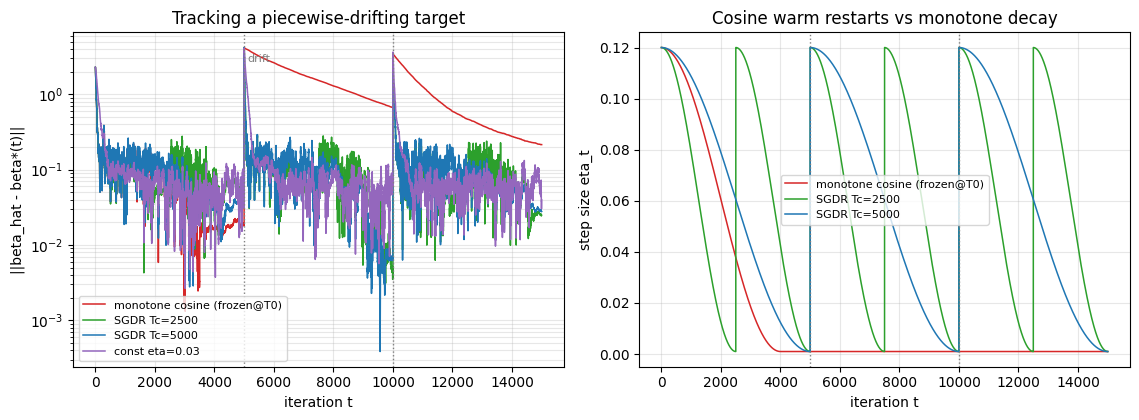

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.3))
tt = np.arange(1, T + 1)
col = {"monotone cosine (frozen@T0)": '#d62728', "SGDR Tc=2500": '#2ca02c',
       "SGDR Tc=5000": '#1f77b4', "const eta=0.03": '#9467bd'}
for n, err in curves.items():
    ax[0].semilogy(tt, err, color=col[n], lw=1.1, label=n)
for bnd in bounds[1:-1]:
    ax[0].axvline(bnd, color='gray', ls=':', lw=1)
ax[0].text(bounds[1]*1.02, ax[0].get_ylim()[1]*0.4, 'drift', color='gray', fontsize=8)
ax[0].set_xlabel('iteration t'); ax[0].set_ylabel('||beta_hat - beta*(t)||')
ax[0].set_title('Tracking a piecewise-drifting target')
ax[0].legend(fontsize=8); ax[0].grid(True, which='both', alpha=0.3)

for n in ["monotone cosine (frozen@T0)", "SGDR Tc=2500", "SGDR Tc=5000"]:
    eta_seq = np.array([scheds[n](t) for t in range(T)])
    ax[1].plot(tt, eta_seq, color=col[n], lw=1.1, label=n)
for bnd in bounds[1:-1]:
    ax[1].axvline(bnd, color='gray', ls=':', lw=1)
ax[1].set_xlabel('iteration t'); ax[1].set_ylabel('step size eta_t')
ax[1].set_title('Cosine warm restarts vs monotone decay')
ax[1].legend(fontsize=8); ax[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 4. 결과 해석

측정된 구간별 tail(각 구간 마지막 800스텝 평균):

| 스케줄 | seg1 (정상) | seg2 (1차 드리프트 후) | seg3 (2차 드리프트 후) |
|---|---|---|---|
| monotone cosine (frozen@T0) | **0.018** | 0.762 | 0.235 |
| SGDR Tc=2500 | 0.056 | 0.018 | 0.037 |
| SGDR Tc=5000 | 0.030 | **0.008** | 0.038 |
| const eta=0.03 | 0.063 | 0.046 | 0.064 |

1. **단조 cosine(빨강)**: 1구간(정상)에서는 감쇠 덕에 **가장 낮은 0.018** 로 수렴한다. 그러나 $t{=}4000$ 에서
   $\eta$ 가 이미 $\eta_{\min}$ 로 동결됐기 때문에, $t{=}5000$ 의 목표 점프 이후 **거의 못 따라가** seg2 오차가
   **0.76** 로 폭증한다(§2.1 추적 실패). seg3 도 0.235 로 높게 갇힌다.
2. **SGDR(초록/파랑)**: 각 주기가 $\eta_{\max}$ 로 재상승(우측 톱니)해, 드리프트 직후에도 큰 스텝으로 새 목표에
   **빠르게 재수렴**한다 — seg2·seg3 tail 이 단조 대비 한두 자릿수 낮다. 정상성 가정이 깨진 환경에서 견고하다.
3. **$T_c$ 트레이드오프**: 긴 $T_c{=}5000$ 은 주기당 더 깊이 담금질해 seg1·seg2 바닥이 더 낮고(0.030, 0.008),
   짧은 $T_c{=}2500$ 은 재시작이 잦아 잡음이 조금 크지만 어떤 구간에서도 안정적으로 추적한다 — 드리프트 빈도에
   맞춘 편향-분산 절충.
4. **상수 $\eta$(보라)**: 추적은 늘 되지만(스텝이 안 죽음) 잡음 바닥이 높아(≈0.05–0.06) 정상 구간에서 스케줄 대비 손해다.

> **결론**: 목표가 **드리프트**하면 일찍 얼어붙은 단조 감쇠는 추적력을 잃는다(seg2 0.76). **코사인 웜 리스타트(SGDR)**
> 는 학습률을 주기적으로 되살려 재수렴 능력을 회복하며, 재시작 주기 $T_c$ 가 **추적 속도 ↔ 잡음 바닥**의 손잡이다.

**단원 마무리**: §14.9 로 학습률 **스케줄** 삼부작을 마쳤다 — (P1) 계단·$1/\sqrt t$ 감쇠로 잡음 바닥 낮추기,
(P2) 워밍업+코사인으로 초기 안정과 부드러운 착륙, (P3) 웜 리스타트로 드리프트 추적. 모두 §14.7–14.8 과
같은 **편향-분산·전처리** 이야기의 시간축 버전이다. 다음 Day 는 스케줄과 적응법을 결합한 **하이퍼파라미터
자동 탐색/스케줄 메타학습**, 또는 정규 교재 절 순서로의 복귀로 이어 갈 수 있다.